In [156]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision

# **Parameter initialization and data preparation**

In [157]:
# Parameters
batch_size = 8
num_epochs = 5
device = 'cuda:0'
num_classes = 10

# Load dataset
transform = torchvision.transforms.Compose(
    [torchvision.transforms.ToTensor(),
     torchvision.transforms.Normalize((0.5), (0.5))])

trainset = torchvision.datasets.MNIST(root='./data', train=True,
                                        download=True, transform=transform)
valset = torchvision.datasets.MNIST(root='./data', train=False,
                                       download=True, transform=transform)

print(trainset)

# Create dataloaders
trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size,
                                          shuffle=True)
valloader = torch.utils.data.DataLoader(valset, batch_size=batch_size,
                                         shuffle=False)

Dataset MNIST
    Number of datapoints: 60000
    Root location: ./data
    Split: Train
    StandardTransform
Transform: Compose(
               ToTensor()
               Normalize(mean=0.5, std=0.5)
           )


In [158]:
def imshow(img):
    img = img / 2 + 0.5     # unnormalize to show images correctly
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()

torch.Size([8, 1, 28, 28])


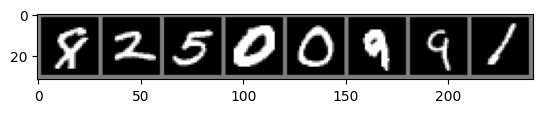

    8     2     5     0     0     9     9     1


In [159]:
# Print some samples of dataset as a sanity check

# Get some random training images
dataiter = iter(trainloader)
example_images, example_labels = next(dataiter)

print(example_images.shape)

# Show images
imshow(torchvision.utils.make_grid(example_images))
# Print labels
print(' '.join('%5s' % example_labels[j].item() for j in range(batch_size)))

# **Define Models**

In [160]:
class Autoencoder(nn.Module):
    def __init__(self):
        super().__init__()
        # >> Your code goes here <<

    def forward(self, x):
        # >> Your code goes here <<
        return x

# **Make a training loop**

In [161]:
def compute_run_acc(logits, labels):
    _, pred = torch.max(logits.data, 1)
    return (pred == labels).sum().item()

In [162]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

In [163]:
class Autoencoder(nn.Module):
    def __init__(self):
        super().__init__()
        # Define the encoder layers
        self.conv1 = nn.Conv2d(1, 4, 3,stride=1, padding="same")
        self.pool = nn.MaxPool2d(2,stride=2)
        self.conv2 = nn.Conv2d(4, 8, 3,stride=1, padding="same")
        self.conv3 = nn.Conv2d(8, 16, 3,stride=1, padding=2)


        # Define the decoder layers
        self.conv4 = nn.Conv2d(16, 16, 3,stride=1, padding=1)
        self.upsmaple=nn.Upsample(scale_factor=2, mode='bilinear')
        self.conv5 = nn.Conv2d(16, 8, 3,stride=1, padding="same")
        self.conv6 = nn.Conv2d(8, 4, 3,stride=1, padding=0)
        self.conv7 = nn.Conv2d(4, 1, 3,stride=1, padding="same")




    def forward(self, x):
        # Flatten the input image
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))
        x = self.upsmaple(F.relu(self.conv4(x)))
        x = self.upsmaple(F.relu(self.conv5(x)))
        x = self.upsmaple(F.relu(self.conv6(x)))
        x = self.conv7(x) # Removed the final upsampling to match input size
        #x = self.upsmaple(F.relu(self.conv7(x)))

        return x

In [ ]:
# Instantiate model and optimizer

model = Autoencoder().to(device)

print("Number of trainable parameters: {}".format(count_parameters(model)))

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)
best_val_loss = np.inf

tr_losses = np.zeros(num_epochs)
val_losses = np.zeros(num_epochs)

for epoch_nr in range(num_epochs):

    print("Epoch {}:".format(epoch_nr))

    # Train model
    running_loss = 0.0
    running_acc=0
    # Train model
    # >> Your code goes here <<
    for batch_data, batch_labels in trainloader:
      batch_data = batch_data.to(device)
      #batch_labels = batch_labels.to(device)
      optimizer.zero_grad()
      logits = model(batch_data)
      loss = criterion(logits, batch_data)
      loss.backward()
      optimizer.step()
      running_loss += loss.item()
      running_acc += compute_run_acc(logits, batch_data)
    # You can re-use code from previous exercises but don't forget that we
    # the input image is also the label

    # Print results
    tr_loss = running_loss/len(trainloader.dataset)
    print('>> TRAIN: Epoch {} completed | tr_loss: {:.4f}'.format(
        epoch_nr, running_loss/len(trainloader.dataset)))

    # Get validation results
    running_loss = 0

    # >> Your code goes here <<
    running_eval_loss = 0.0
    for batch_data, batch_labels in valloader:
      batch_data = batch_data.to(device)
      #batch_labels = batch_labels.to(device)
      logits = model(batch_data)
      loss = criterion(logits, batch_data)
      running_eval_loss += loss.item()
    val_loss = running_eval_loss/len(valloader.dataset)
    print('>> VALIDATION: Epoch {} | val_loss: {:.4f}'.format(epoch_nr, val_loss))

    tr_losses[epoch_nr] = tr_loss
    val_losses[epoch_nr] = val_loss

print('Training finished')

Number of trainable parameters: 5313
Epoch 0:


# **Investigate results**

In [ ]:
plt.figure()
plt.plot(tr_losses, label='Training')
plt.plot(val_losses, label='Validation')
plt.title('Results')
plt.ylabel('MSE')
plt.xlabel('Epochs')
plt.legend()
plt.show()

In [ ]:
# Check some reconstructions by the trained model

# Get some random validation images
dataiter = iter(valloader)
example_images, _ = dataiter.next()

print(example_images.shape)

# Show images
imshow(torchvision.utils.make_grid(example_images))
preds = model(example_images.to(device))
imshow(torchvision.utils.make_grid(preds.cpu()))
# Print labels
print(' '.join('%5s' % example_labels[j].item() for j in range(batch_size)))